<a href="https://colab.research.google.com/github/NagaJahnaviD/Sarcasam-Detection/blob/main/Sarcasm_detection_in_text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Sarcasm Detection on Twitter
###Feature Engineering Study

In [ ]:
!pip install -q vaderSentiment shap transformers datasets \
    scikit-learn xgboost plotly seaborn wordcloud ipywidgets \
    emoji tqdm requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 36.0 MB/s eta 0:00:00


In [ ]:
import os, re, json, warnings, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
warnings.filterwarnings('ignore')

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
nltk.download('punkt',                          quiet=True)
nltk.download('punkt_tab',                      quiet=True)
nltk.download('stopwords',                      quiet=True)
nltk.download('averaged_perceptron_tagger',     quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

import emoji
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import chi2
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score,
                              precision_score, recall_score)
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
import shap

import torch
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           BertTokenizer, BertForSequenceClassification, BertConfig,
                           Trainer, TrainingArguments, EarlyStoppingCallback)
from torch.utils.data import Dataset

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from wordcloud import WordCloud
from tqdm.auto import tqdm
tqdm.pandas()

SEED = 42
np.random.seed(SEED)
analyzer  = SentimentIntensityAnalyzer()
STOPWORDS = set(stopwords.words('english'))

In [ ]:
#loading dataset
TRAIN_URL = 'https://raw.githubusercontent.com/EducationalTestingService/sarcasm/refs/heads/master/twitter/sarcasm_detection_shared_task_twitter_training.jsonl'
TEST_URL  = 'https://raw.githubusercontent.com/EducationalTestingService/sarcasm/refs/heads/master/twitter/sarcasm_detection_shared_task_twitter_testing.jsonl'

def load_jsonl_url(url):
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    return [json.loads(l) for l in r.text.strip().split('\n') if l.strip()]

def jsonl_to_df(records):
    rows = []
    for rec in records:
        context  = rec.get('context', [])
        parent   = context[-1] if context else ''
        full_ctx = ' '.join(context)
        rows.append({
            'response'    : rec['response'],
            'parent'      : parent,
            'full_context': full_ctx,
            'label'       : 1 if rec['label'] == 'SARCASM' else 0
        })
    return pd.DataFrame(rows)

train_raw = load_jsonl_url(TRAIN_URL)
test_raw  = load_jsonl_url(TEST_URL)
train_df  = jsonl_to_df(train_raw)
test_df   = jsonl_to_df(test_raw)
train_df.head(3)

,response,parent,full_context,label
0,@USER @USER @USER I don't get this .. obviousl...,@USER If your child isn't named Barron ... #Be...,A minor child deserves privacy and should be k...,1
1,@USER @USER trying to protest about . Talking ...,@USER @USER having to make up excuses of why y...,@USER @USER Why is he a loser ? He's just a Pr...,1
2,@USER @USER @USER He makes an insane about of ...,@USER I ’ ll remember to not support you at th...,Donald J . Trump is guilty as charged . The ev...,1


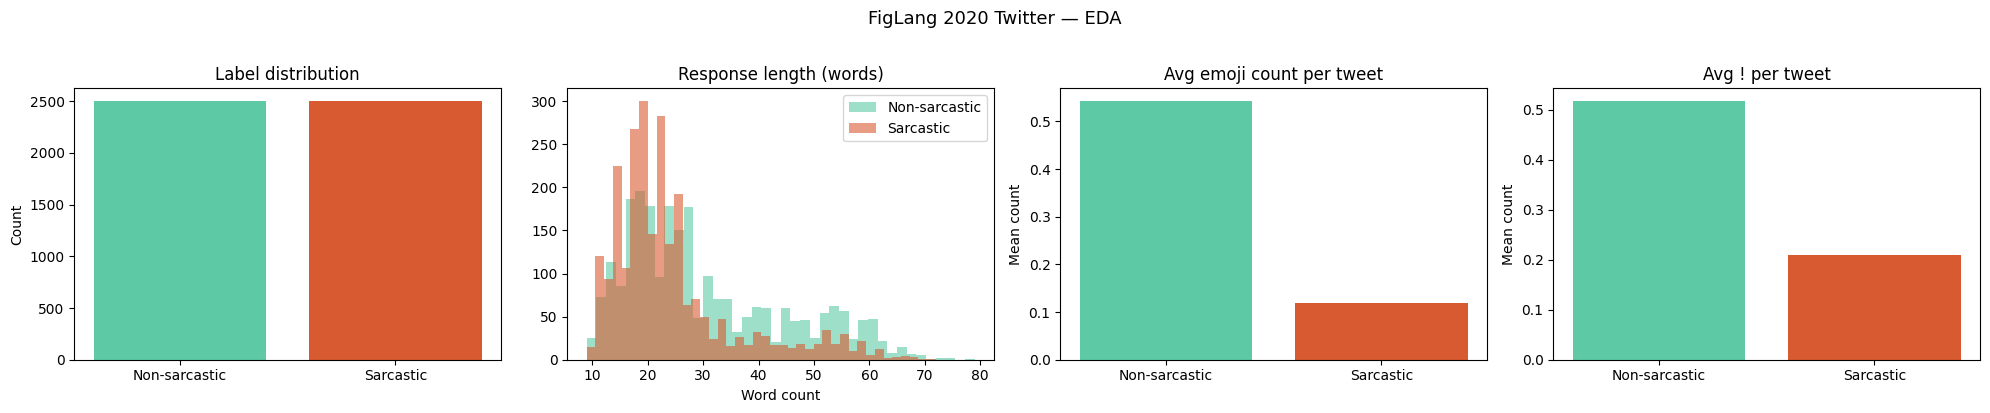

In [ ]:
#EDA
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

counts = train_df['label'].value_counts().sort_index()
axes[0].bar(['Non-sarcastic', 'Sarcastic'], counts.values,
            color=['#5DCAA5', '#D85A30'])
axes[0].set_title('Label distribution')
axes[0].set_ylabel('Count')

train_df['resp_len'] = train_df['response'].str.split().str.len()
axes[1].hist(train_df[train_df.label==0]['resp_len'], bins=40,
             alpha=0.6, label='Non-sarcastic', color='#5DCAA5')
axes[1].hist(train_df[train_df.label==1]['resp_len'], bins=40,
             alpha=0.6, label='Sarcastic',     color='#D85A30')
axes[1].set_title('Response length (words)')
axes[1].set_xlabel('Word count')
axes[1].legend()

def count_emojis(text):
    return sum(1 for c in str(text) if c in emoji.EMOJI_DATA)
train_df['emoji_count_eda'] = train_df['response'].apply(count_emojis)
emoji_rate = train_df.groupby('label')['emoji_count_eda'].mean()
axes[2].bar(['Non-sarcastic', 'Sarcastic'], emoji_rate.values,
            color=['#5DCAA5', '#D85A30'])
axes[2].set_title('Avg emoji count per tweet')
axes[2].set_ylabel('Mean count')

exclaim_rate = train_df.groupby('label')['response'].apply(
    lambda s: s.str.count('!').mean())
axes[3].bar(['Non-sarcastic', 'Sarcastic'], exclaim_rate.values,
            color=['#5DCAA5', '#D85A30'])
axes[3].set_title('Avg ! per tweet')
axes[3].set_ylabel('Mean count')

plt.suptitle('FigLang 2020 Twitter — EDA', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Feature Extraction

### Feature Groups

| Group | Features | Approach |
|-------|----------|----------|
| **A — Standard NLP** | TF-IDF, VADER, POS ratios, lexical diversity | Standard |
| **B — Rhetorical** | Continuous polarity gap, fake-agree, rhetorical q, neg+pos pair score, neg+exclaim | **Continuous** |
| **C — Casing** | caps ratio, ALL-CAPS words, mixed case | Standard |
| **D — Punctuation** | `!`, `?`, `!!`, `??`, `?!`, `...` | Standard |
| **E — Intensifiers** | count, density ratio, weighted combo score | **Continuous** |
| **F — Sentiment Incongruity** | sentence-level VADER variance, range, half-split score, sign flip | **Continuous** |
| **G — Context Mismatch** | sentiment gap, polarity flip, **TF-IDF cosine similarity** | **Continuous** |
| **H — Emoji** | count, sarcastic/pos/neg flags, sentiment mismatch, density | Standard |
| **I — Twitter-Specific** | hashtags, mentions, URL, RT, char count, sarcasm hashtag | Standard |
| **J — Hyperbole & Irony** | superlatives, exaggeration, irony opener, obviousness, positive-then-neg, contrast | Standard |

**Groups B, E, F, G are the improved continuous versions replacing the original binary/static checks.**

In [ ]:
# LEXICONS — shared across feature groups

POSITIVE_WORDS = {
    'great','amazing','wonderful','fantastic','excellent','brilliant',
    'love','best','perfect','awesome','good','nice','fine','helpful',
    'beautiful','incredible','outstanding','superb','magnificent','terrific'
}

NEGATIVE_WORDS = {
    'disaster','catastrophe','terrible','awful','pathetic','useless',
    'horrible','dreadful','atrocious','abysmal','appalling','disgraceful',
    'outrageous','unbearable','deplorable','worst','garbage','trash','crap'
}

FAKE_AGREE_OPENERS = {
    'sure','right','yeah','yep','yes','oh','wow','great','wonderful',
    'brilliant','perfect','fantastic','excellent','totally','absolutely'
}

NEGATIONS = {'not','never','no','hardly','barely','scarcely','neither','nor'}

INTENSIFIERS = {
    'totally','absolutely','definitely','clearly','obviously','certainly',
    'surely','undoubtedly','literally','seriously','honestly','really',
    'truly','perfectly','exactly','so','very','extremely','incredibly'
}

SUPERLATIVES = {
    'best','worst','greatest','most','least','ever','never','always',
    'everyone','nobody','everything','nothing','everywhere','nowhere'
}

EXAGGERATION_MARKERS = {
    'literally','actually','unbelievable','shocking','insane','crazy',
    'ridiculous','absurd','hilarious','priceless','genius','brilliant'
}

IRONY_OPENERS = {
    'wow','oh','gee','gosh','goodness','well','shocking','surprise',
    'shocker','imagine','unbelievable','colour me','who knew'
}

OBVIOUSNESS_WORDS = {
    'obviously','clearly','of course','naturally','evidently','surely',
    'apparently','needless to say','goes without saying'
}

SARCASTIC_EMOJIS = {'🙄','😒','🤦','🤷','😑','😐','🙃','😬','🤨','💀','☠️','🫠','😏'}
POSITIVE_EMOJIS  = {'😊','😀','😄','❤️','👍','🎉','✨','🥰','😍','💕','🌟','💪'}
NEGATIVE_EMOJIS  = {'😢','😭','😤','😡','🤬','😠','💔','😞','😩','😫','🤮','🤯'}

print('Lexicons defined.')

Lexicons defined.


In [ ]:
# GROUP A: Standard NLP features

def vader_features(text):
    s = analyzer.polarity_scores(str(text))
    return s['compound'], s['pos'], s['neg'], s['neu']
    #retuns overall sentiment, positive proportion, neg proportion, neutral propportion

def pos_features(text):
    try:
        tokens = word_tokenize(str(text).lower())
        tags   = nltk.pos_tag(tokens)
        n      = max(len(tags), 1)
        adj    = sum(1 for _, t in tags if t.startswith('JJ')) / n
        adv    = sum(1 for _, t in tags if t.startswith('RB')) / n
        verb   = sum(1 for _, t in tags if t.startswith('VB')) / n
        return adj, adv, verb
    except Exception:
        return 0.0, 0.0, 0.0
    #ratios of parts of speech

def lexical_features(text):
    tokens = str(text).lower().split()
    if not tokens:
        return 0.0, 0.0
    ttr     = len(set(tokens)) / len(tokens)
    avg_len = np.mean([len(t) for t in tokens])
    return ttr, avg_len
    #measure vocab diversity, complexity of language
print('Standard NLP defined.')

Standard NLP defined.


In [ ]:
# GROUP B: Rhetorical features
def rhetorical_features(text):
    text_str   = str(text)
    tokens     = text_str.lower().split()
    clean_toks = [t.strip('.,!?;:\'\"@#') for t in tokens]

    # Polarity gap — VADER scores of positive-sentiment sentences
    # vs negative-sentiment sentences (no word list needed)
    sentences  = sent_tokenize(text_str) if len(text_str) > 10 else [text_str]
    pos_scores, neg_scores = [], []
    for sent in sentences:
        sc = analyzer.polarity_scores(sent)['compound']
        if sc > 0.2:
            pos_scores.append(sc)
        elif sc < -0.2:
            neg_scores.append(sc)
    avg_pos = np.mean(pos_scores) if pos_scores else 0.0
    avg_neg = np.mean(neg_scores) if neg_scores else 0.0
    polarity_gap_score = float(avg_pos - avg_neg)

    first_word = clean_toks[0] if clean_toks else ''
    starts_fake_agree = int(first_word in FAKE_AGREE_OPENERS)

    QUESTION_WORDS = {'why','how','what','who','when','where','really','seriously'}
    ends_with_q    = text_str.strip().endswith('?')
    has_q_word     = any(t in QUESTION_WORDS for t in clean_toks[:5])
    has_rhetorical_q = int(ends_with_q or has_q_word)

    # Negation + positive word - weighted by VADER score of the next word
    #eg: not great, not good
    neg_pos_score = 0.0
    for i in range(len(clean_toks) - 1):
        if clean_toks[i] in NEGATIONS:
            next_score = analyzer.polarity_scores(clean_toks[i+1])['compound']
            if next_score > 0.0:
                neg_pos_score += next_score

    # Negative exclaim - VADER of full tweet < -0.1 AND has !
    overall_sent = analyzer.polarity_scores(text_str)['compound']
    neg_exclaim  = int('!' in text_str and overall_sent < -0.1)

    return polarity_gap_score, starts_fake_agree, has_rhetorical_q, neg_pos_score, neg_exclaim
print('Rhetorical defined')

Rhetorical defined


In [ ]:
# GROUP C: Casing Features

def casing_features(text):
    text    = str(text)
    letters = [c for c in text if c.isalpha()]
    if not letters:
        return 0.0, 0.0, 0
    caps_ratio = sum(1 for c in letters if c.isupper()) / len(letters)
    words      = text.split()
    caps_words = sum(1 for w in words if w.isupper() and len(w) > 1) / max(len(words), 1)
    mixed = 0
    for w in words:
        alpha = [c for c in w if c.isalpha()]
        if len(alpha) > 3:
            alts = sum(1 for i in range(1, len(alpha))
                       if alpha[i].isupper() != alpha[i-1].isupper())
            if alts >= len(alpha) * 0.6:
                mixed = 1
                break
    return caps_ratio, caps_words, mixed

print('Casing defined.')

Casing defined.


In [ ]:
# GROUP D: Punctuation Features

def punctuation_features(text):
    text = str(text)
    return (
        text.count('!'),
        text.count('?'),
        int(bool(re.search(r'!{2,}', text))),#multiple !
        int(bool(re.search(r'\?{2,}', text))),#multiple ?
        int(bool(re.search(r'[?!][!?]', text))),
        int(bool(re.search(r'\.{3,}', text))),#ellipsis
    )

print('Punctuation defined.')

Punctuation defined.


In [ ]:
# GROUP E: Intensifier Features
def intensifier_features(text):
    tokens  = str(text).lower().split()
    n       = max(len(tokens), 1)
    count   = sum(1 for t in tokens if t in INTENSIFIERS)
    density = count / n

    combo_score = 0.0
    for i in range(len(tokens) - 1):
        if tokens[i] in INTENSIFIERS:
            next_score = analyzer.polarity_scores(tokens[i+1])['compound']
            if next_score > 0.0:
                combo_score += next_score

    return count, density, combo_score
print('Intensifiers defined.')

Intensifiers defined.


In [ ]:
# GROUP F: Sentiment Incongruity

def sentiment_incongruity(text):

    text_str  = str(text)
    sentences = sent_tokenize(text_str)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 3]

    if len(sentences) >= 2:
        sent_scores = [analyzer.polarity_scores(s)['compound'] for s in sentences]
        sent_vader_variance = float(np.var(sent_scores))
        sent_vader_range    = float(max(sent_scores) - min(sent_scores))
    else:
        # Single sentence — compute word-level variance as a proxy
        words = text_str.split()
        if len(words) >= 4:
            word_scores = [analyzer.polarity_scores(w)['compound'] for w in words
                           if analyzer.polarity_scores(w)['compound'] != 0]
            sent_vader_variance = float(np.var(word_scores)) if word_scores else 0.0
            sent_vader_range    = float(max(word_scores) - min(word_scores)) if word_scores else 0.0
        else:
            sent_vader_variance = 0.0
            sent_vader_range    = 0.0

    # Keep original half-split as a secondary signal
    words = text_str.split()
    if len(words) >= 4:
        mid    = len(words) // 2
        first  = analyzer.polarity_scores(' '.join(words[:mid]))['compound']
        second = analyzer.polarity_scores(' '.join(words[mid:]))['compound']
        inc_score = abs(first - second)
        inc_flip  = int((first > 0.1 and second < -0.1) or (first < -0.1 and second > 0.1))
    else:
        overall   = analyzer.polarity_scores(text_str)['compound']
        inc_score = 0.0
        inc_flip  = 0

    return sent_vader_variance, sent_vader_range, inc_score, inc_flip

print('Sentiment Incongruity defined.')

Sentiment Incongruity defined.


In [ ]:
# GROUP G: Context Mismatch

def context_mismatch(response, parent, tfidf_ctx=None):

    resp_s   = analyzer.polarity_scores(str(response))['compound']
    parent_s = analyzer.polarity_scores(str(parent))['compound'] if parent else 0.0
    gap      = abs(resp_s - parent_s)
    flip     = int((resp_s > 0.1 and parent_s < -0.1) or
                   (resp_s < -0.1 and parent_s > 0.1))
    pos_to_neg = int(resp_s > 0.2 and parent_s < -0.1)

    # TF-IDF cosine similarity between parent and response
    if tfidf_ctx is not None and parent and str(parent).strip():
        try:
            vecs = tfidf_ctx.transform([str(parent), str(response)])
            sim  = float(cosine_similarity(vecs[0], vecs[1])[0][0])
        except Exception:
            sim = 0.5
    else:
        sim = 0.5  # neutral when no parent available

    return parent_s, resp_s, gap, flip, pos_to_neg, sim

print('Context Mismatch defined.')

Context Mismatch defined.


In [ ]:
# GROUP H: Emoji Features
def emoji_features(text):
    text_str   = str(text)
    all_emojis = [c for c in text_str if c in emoji.EMOJI_DATA]
    em_count   = len(all_emojis)
    em_set     = set(all_emojis)
    has_sarc   = int(bool(em_set & SARCASTIC_EMOJIS))
    has_pos    = int(bool(em_set & POSITIVE_EMOJIS))
    has_neg    = int(bool(em_set & NEGATIVE_EMOJIS))
    vader_compound = analyzer.polarity_scores(text_str)['compound']
    mismatch   = int(has_pos and vader_compound < -0.1)
    density    = em_count / max(len(text_str.split()), 1)
    return em_count, has_sarc, has_pos, has_neg, mismatch, density

print('Emoji defined.')

Emoji defined.


In [ ]:
# GROUP I: Twitter Specific Features

def twitter_features(text):
    text_str      = str(text)
    hashtags      = re.findall(r'#\w+', text_str)
    mentions      = re.findall(r'@\w+', text_str)
    hashtag_count = len(hashtags)
    mention_count = len(mentions)
    has_url       = int(bool(re.search(r'https?://\S+|t\.co/\S+', text_str)))
    is_retweet    = int(text_str.strip().startswith('RT @'))
    char_count    = len(text_str)
    sarc_tags     = {'sarc','sarcasm','irony','ironic','notreally','yeahright'}
    has_sarc_tag  = int(any(h.lstrip('#').lower() in sarc_tags for h in hashtags))
    return hashtag_count, mention_count, has_url, is_retweet, char_count, has_sarc_tag

print('Twitter-Specific defined.')

Twitter-Specific defined.


In [ ]:
# GROUP J: Hyperbole & Irony Markers
def hyperbole_irony_features(text):
    text_str = str(text)
    tokens   = text_str.lower().split()
    clean_toks = [t.strip('.,!?;:\'\"@#') for t in tokens]

    try:
        pos_tags = nltk.pos_tag(word_tokenize(text_str.lower()))
        superlative_count = sum(1 for _, tag in pos_tags if tag in ('JJS', 'RBS'))
    except Exception:
        superlative_count = 0

    # Exaggeration — words with very high absolute VADER score (|score| > 0.6)
    exaggeration_count = sum(
        1 for t in clean_toks
        if abs(analyzer.polarity_scores(t)['compound']) > 0.6
    )

    # Unchanged structural features
    first_word   = clean_toks[0] if clean_toks else ''
    irony_opener = int(first_word in IRONY_OPENERS)

    obviousness_count = sum(1 for t in clean_toks if t in OBVIOUSNESS_WORDS)

    # Positive start, negative end
    words = text_str.split()
    if len(words) >= 6:
        start_sent        = analyzer.polarity_scores(' '.join(words[:3]))['compound']
        end_sent          = analyzer.polarity_scores(' '.join(words[-3:]))['compound']
        positive_then_neg = int(start_sent > 0.2 and end_sent < -0.1)
    else:
        positive_then_neg = 0

    CONTRAST = {'but','yet','however','though','although','whereas','despite','still'}
    contrast_conjunctions = sum(1 for t in clean_toks if t in CONTRAST)

    return (superlative_count, exaggeration_count, irony_opener,
            obviousness_count, positive_then_neg, contrast_conjunctions)
print('Hyperbole & Irony defined.')

Hyperbole & Irony defined.


In [ ]:
# MASTER FEATURE EXTRACTOR
#
# Fit a small TF-IDF on train corpus first — used inside context_mismatch
# to compute cosine similarity between parent and response.

print('Fitting context TF-IDF vectorizer on training corpus...')
tfidf_ctx = TfidfVectorizer(max_features=3000, ngram_range=(1,1),
                             min_df=2, strip_accents='unicode')
ctx_corpus = pd.concat([
    train_df['response'], train_df['parent']
]).fillna('').tolist()
tfidf_ctx.fit(ctx_corpus)
print(f'Context TF-IDF fitted on {len(ctx_corpus)} texts.')


def extract_all_features(df, tfidf_ctx_vec):
    records = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Extracting features'):
        resp   = row['response']
        parent = row.get('parent', '')

        # A — Standard NLP
        v_compound, v_pos, v_neg, v_neu = vader_features(resp)
        pos_adj, pos_adv, pos_verb      = pos_features(resp)
        ttr, avg_wlen                   = lexical_features(resp)
        word_count                      = len(str(resp).split())

        # B — Rhetorical (continuous)
        pol_gap, fake_ag, rhet_q, neg_score, neg_ex = rhetorical_features(resp)

        # C — Casing
        caps_ratio, caps_words, mixed_case = casing_features(resp)

        # D — Punctuation
        ex_cnt, q_cnt, multi_ex, multi_q, interro, ellipsis = punctuation_features(resp)

        # E — Intensifiers (continuous)
        int_count, int_density, int_combo = intensifier_features(resp)

        # F — Sentiment incongruity (sentence-level variance)
        sent_var, sent_range, inc_score, inc_flip = sentiment_incongruity(resp)

        # G — Context mismatch (with cosine similarity)
        par_sent, res_sent, ctx_gap, ctx_flip, pos_to_neg, ctx_sim = context_mismatch(resp, parent, tfidf_ctx_vec)

        # H — Emoji
        em_count, em_sarc, em_pos, em_neg, em_mismatch, em_density = emoji_features(resp)

        # I — Twitter-Specific
        ht_count, men_count, has_url, is_rt, char_cnt, sarc_tag = twitter_features(resp)

        # J — Hyperbole & Irony
        sup_cnt, exag_cnt, irony_open, obv_cnt, pos_then_neg, contrast_cnt = hyperbole_irony_features(resp)

        records.append({
            # A
            'vader_compound'          : v_compound,
            'vader_pos'               : v_pos,
            'vader_neg'               : v_neg,
            'vader_neu'               : v_neu,
            'pos_adj_ratio'           : pos_adj,
            'pos_adv_ratio'           : pos_adv,
            'pos_verb_ratio'          : pos_verb,
            'type_token_ratio'        : ttr,
            'avg_word_length'         : avg_wlen,
            'word_count'              : word_count,
            # B
            'polarity_gap_score'      : pol_gap,
            'starts_fake_agree'       : fake_ag,
            'has_rhetorical_q'        : rhet_q,
            'neg_pos_score'           : neg_score,
            'neg_exclaim'             : neg_ex,
            # C
            'caps_ratio'              : caps_ratio,
            'caps_words_ratio'        : caps_words,
            'mixed_casing'            : mixed_case,
            # D
            'exclaim_count'           : ex_cnt,
            'question_count'          : q_cnt,
            'multi_exclaim'           : multi_ex,
            'multi_question'          : multi_q,
            'interrobang'             : interro,
            'ellipsis'                : ellipsis,
            # E
            'intensifier_count'       : int_count,
            'intensifier_density'     : int_density,
            'intensifier_combo_score' : int_combo,
            # F
            'sent_vader_variance'     : sent_var,
            'sent_vader_range'        : sent_range,
            'incongruity_score'       : inc_score,
            'incongruity_sign_flip'   : inc_flip,
            # G
            'parent_sentiment'        : par_sent,
            'response_sentiment'      : res_sent,
            'context_sentiment_gap'   : ctx_gap,
            'context_flip'            : ctx_flip,
            'context_pos_to_neg'      : pos_to_neg,
            'context_topic_sim'       : ctx_sim,
            # H
            'emoji_count'             : em_count,
            'emoji_sarcastic'         : em_sarc,
            'emoji_positive'          : em_pos,
            'emoji_negative'          : em_neg,
            'emoji_sentiment_mismatch': em_mismatch,
            'emoji_density'           : em_density,
            # I
            'hashtag_count'           : ht_count,
            'mention_count'           : men_count,
            'has_url'                 : has_url,
            'is_retweet'              : is_rt,
            'char_count'              : char_cnt,
            'has_sarcasm_hashtag'     : sarc_tag,
            # J
            'superlative_count'       : sup_cnt,
            'exaggeration_count'      : exag_cnt,
            'irony_opener'            : irony_open,
            'obviousness_count'       : obv_cnt,
            'positive_then_negative'  : pos_then_neg,
            'contrast_conjunctions'   : contrast_cnt,
        })
    return pd.DataFrame(records)


print('Extracting training features ...')
train_feats = extract_all_features(train_df, tfidf_ctx)
print('Extracting test features...')
test_feats  = extract_all_features(test_df, tfidf_ctx)

y_train = train_df['label'].values
y_test  = test_df['label'].values

print(f'\nFeature matrix: {train_feats.shape[1]} features × {train_feats.shape[0]} training examples')
train_feats.describe().round(3)

Fitting context TF-IDF vectorizer on training corpus...
Context TF-IDF fitted on 10000 texts.
Extracting training features ...


Extracting features:   0%|          | 0/5000 [00:00<?, ?it/s]

Extracting test features...


Extracting features:   0%|          | 0/1800 [00:00<?, ?it/s]


Feature matrix: 55 features × 5000 training examples


,vader_compound,vader_pos,vader_neg,vader_neu,pos_adj_ratio,pos_adv_ratio,pos_verb_ratio,type_token_ratio,avg_word_length,word_count,...,has_url,is_retweet,char_count,has_sarcasm_hashtag,superlative_count,exaggeration_count,irony_opener,obviousness_count,positive_then_negative,contrast_conjunctions
count,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,...,5000.0,5000.0,5000.000,5000.00,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000
mean,0.188,0.139,0.077,0.784,0.078,0.056,0.176,0.856,4.099,27.304,...,0.0,0.0,136.448,0.00,0.062,0.247,0.001,0.020,0.009,0.198
std,0.548,0.129,0.094,0.134,0.053,0.047,0.062,0.080,0.608,13.415,...,0.0,0.0,64.592,0.02,0.260,0.673,0.032,0.139,0.092,0.460
min,-0.962,0.000,0.000,0.311,0.000,0.000,0.000,0.474,2.200,9.000,...,0.0,0.0,39.000,0.00,0.000,0.000,0.000,0.000,0.000,0.000
25%,-0.248,0.000,0.000,0.694,0.042,0.019,0.133,0.805,3.692,18.000,...,0.0,0.0,92.000,0.00,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.250,0.121,0.048,0.789,0.071,0.049,0.174,0.857,4.045,23.000,...,0.0,0.0,117.000,0.00,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.670,0.213,0.130,0.877,0.111,0.083,0.214,0.913,4.455,33.000,...,0.0,0.0,164.000,0.00,0.000,0.000,0.000,0.000,0.000,0.000
max,0.996,0.689,0.558,1.000,0.333,0.375,0.545,1.000,8.286,79.000,...,0.0,0.0,315.000,1.00,3.000,10.000,1.000,1.000,1.000,4.000


In [ ]:
# TF-IDF (unigram + bigram, Twitter-aware preprocessing)
def clean_for_tfidf(text):
    text = re.sub(r'https?://\S+|t\.co/\S+', 'URL', str(text))
    text = re.sub(r'@\w+', 'USER', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    return text.lower()

train_clean = train_df['response'].apply(clean_for_tfidf)
test_clean  = test_df['response'].apply(clean_for_tfidf)

tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1, 2),
                        strip_accents='unicode', min_df=3,
                        sublinear_tf=True)
X_tfidf_train = tfidf.fit_transform(train_clean)
X_tfidf_test  = tfidf.transform(test_clean)

X_hand_train = csr_matrix(train_feats.values.astype(float))
X_hand_test  = csr_matrix(test_feats.values.astype(float))

X_train_full = hstack([X_tfidf_train, X_hand_train])
X_test_full  = hstack([X_tfidf_test,  X_hand_test])

X_train_hc = train_feats.values.astype(float)
X_test_hc  = test_feats.values.astype(float)

print(f'Full feature matrix : {X_train_full.shape}')
print(f'Handcrafted only    : {X_train_hc.shape}')

Full feature matrix : (5000, 8055)
Handcrafted only    : (5000, 55)


##Model Training & Comparison

In [ ]:
# ── Logistic Regression ──
print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED, n_jobs=-1)
lr.fit(X_train_full, y_train)
y_pred_lr = lr.predict(X_test_full)
print('LR done.')

# ── XGBoost ──
print('Training XGBoost...')
xgb_model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='logloss',
    random_state=SEED, n_jobs=-1, verbosity=0)
xgb_model.fit(X_train_full, y_train,
              eval_set=[(X_test_full, y_test)], verbose=False)
y_pred_xgb = xgb_model.predict(X_test_full)
print('XGBoost done.')

Training Logistic Regression...
LR done.
Training XGBoost...
XGBoost done.


In [ ]:
import os, re, json, warnings, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
warnings.filterwarnings('ignore')

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
nltk.download('punkt',                          quiet=True)
nltk.download('punkt_tab',                      quiet=True)
nltk.download('stopwords',                      quiet=True)
nltk.download('averaged_perceptron_tagger',     quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

import emoji
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import chi2
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score,
                              precision_score, recall_score)
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
import shap

import torch
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           BertTokenizer, BertForSequenceClassification, BertConfig,
                           Trainer, TrainingArguments, EarlyStoppingCallback)
from torch.utils.data import Dataset

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from wordcloud import WordCloud
from tqdm.auto import tqdm
tqdm.pandas()

SEED = 42
np.random.seed(SEED)
analyzer  = SentimentIntensityAnalyzer()
STOPWORDS = set(stopwords.words('english'))

# System B: RoBERTa fine-tuned on parent + response pairs

USE_ROBERTA = torch.cuda.is_available()
print(f'GPU available: {USE_ROBERTA}')
if not USE_ROBERTA:
    print('Switch Colab runtime to GPU (Runtime → Change runtime type → T4 GPU) to enable RoBERTa.')


class SarcasmDatasetContext(Dataset):
    """
    Feeds (parent, response) as a sentence pair.
    The tokenizer inserts [CLS] parent [SEP] response [SEP] automatically.
    RoBERTa then attends across the full pair.
    """
    def __init__(self, responses, parents, labels, tokenizer, max_len=256):
        self.responses = responses
        self.parents   = parents
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.parents[idx],    # sentence A = parent
            self.responses[idx],  # sentence B = response
            max_length   = self.max_len,
            padding      = 'max_length',
            truncation   = True,
            return_tensors = 'pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }


roberta_results = None
roberta_training_losses = [] # Initialize list for training losses
roberta_eval_losses = []     # Initialize list for evaluation losses

if USE_ROBERTA:
    MODEL_NAME = 'roberta-base'
    roberta_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    roberta_model     = AutoModelForSequenceClassification.from_pretrained(
                            MODEL_NAME, num_labels=2)

    # Use full dataset for RoBERTa — it needs more data than BERT to generalise
    tr_responses = train_df['response'].tolist()
    tr_parents   = train_df['parent'].fillna('').tolist()
    te_responses = test_df['response'].tolist()
    te_parents   = test_df['parent'].fillna('').tolist()

    tr_dataset = SarcasmDatasetContext(tr_responses, tr_parents,
                                       y_train.tolist(), roberta_tokenizer)
    te_dataset = SarcasmDatasetContext(te_responses, te_parents,
                                       y_test.tolist(),  roberta_tokenizer)

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return {
            'f1'       : f1_score(labels, preds),
            'accuracy' : accuracy_score(labels, preds)
        }

    roberta_args = TrainingArguments(
        output_dir                  = './roberta_sarcasm',
        num_train_epochs            = 4,
        per_device_train_batch_size = 16,
        per_device_eval_batch_size  = 32,
        learning_rate               = 2e-5,
        warmup_ratio                = 0.1,
        weight_decay                = 0.01,
        eval_strategy         = 'epoch',
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        metric_for_best_model       = 'f1',
        fp16                        = True,   # mixed precision — speeds up T4 GPU
        logging_steps               = 100,
        report_to                   = 'none',
        seed                        = SEED
    )

    roberta_trainer = Trainer(
        model           = roberta_model,
        args            = roberta_args,
        train_dataset   = tr_dataset,
        eval_dataset    = te_dataset,
        compute_metrics = compute_metrics,
        callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
    )

    print('Fine-tuning RoBERTa on parent+response pairs...')
    print('This takes ~20-30 min on T4 GPU.')
    roberta_trainer.train()

    # Extract training and validation loss for plotting
    roberta_loss_data_per_epoch = {'train': {}, 'eval': {}}
    for log in roberta_trainer.state.log_history:
        epoch_num = int(log.get('epoch', -1)) if 'epoch' in log else -1

        if 'loss' in log and epoch_num != -1:
            if epoch_num not in roberta_loss_data_per_epoch['train']:
                roberta_loss_data_per_epoch['train'][epoch_num] = []
            roberta_loss_data_per_epoch['train'][epoch_num].append(log['loss'])
        if 'eval_loss' in log and epoch_num != -1:
            # eval_loss should only be one per epoch
            roberta_loss_data_per_epoch['eval'][epoch_num] = log['eval_loss']

    for epoch in sorted(roberta_loss_data_per_epoch['train'].keys()):
        if roberta_loss_data_per_epoch['train'][epoch]:
            roberta_training_losses.append(roberta_loss_data_per_epoch['train'][epoch][-1])
        if epoch in roberta_loss_data_per_epoch['eval']:
            roberta_eval_losses.append(roberta_loss_data_per_epoch['eval'][epoch])

    preds          = roberta_trainer.predict(te_dataset)
    y_pred_roberta = np.argmax(preds.predictions, axis=1)
    roberta_results = {
        'accuracy' : accuracy_score( y_test, y_pred_roberta),
        'f1'       : f1_score(        y_test, y_pred_roberta),
        'precision': precision_score( y_test, y_pred_roberta),
        'recall'   : recall_score(    y_test, y_pred_roberta)
    }
    print('\nRoBERTa results:', {k: round(v*100,2) for k,v in roberta_results.items()})

    # Save for demo use
    roberta_trainer.save_model('./roberta_sarcasm_final')
    roberta_tokenizer.save_pretrained('./roberta_sarcasm_final')

else:
    print('RoBERTa skipped — no GPU.')

GPU available: True


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


RoBERTa results: {'accuracy': 75.83, 'f1': 77.79, 'precision': 71.95, 'recall': 84.67}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### System C: DistilBERT fine-tuned on parent + response pairs

In [ ]:
distilbert_results = None
distilbert_training_losses = [] # Initialize list for training losses
distilbert_eval_losses = []     # Initialize list for evaluation losses

# Reusing the GPU check from RoBERTa
if USE_ROBERTA:
    print('\nFine-tuning DistilBERT on parent+response pairs...')
    MODEL_NAME_DISTILBERT = 'distilbert-base-uncased'
    distilbert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME_DISTILBERT)
    distilbert_model     = AutoModelForSequenceClassification.from_pretrained(
                            MODEL_NAME_DISTILBERT, num_labels=2)

    # Reusing tr_responses, tr_parents, y_train, te_responses, te_parents, y_test, compute_metrics, SEED
    # The SarcasmDatasetContext class and variables tr_responses, tr_parents, etc., are reused.
    # A new tokenizer (distilbert_tokenizer) is used with the existing Dataset class.
    tr_dataset_distilbert = SarcasmDatasetContext(tr_responses, tr_parents,
                                       y_train.tolist(), distilbert_tokenizer)
    te_dataset_distilbert = SarcasmDatasetContext(te_responses, te_parents,
                                       y_test.tolist(),  distilbert_tokenizer)

    distilbert_args = TrainingArguments(
        output_dir                  = './distilbert_sarcasm',
        num_train_epochs            = 4,
        per_device_train_batch_size = 16,
        per_device_eval_batch_size  = 32,
        learning_rate               = 2e-5,
        warmup_ratio                = 0.1,
        weight_decay                = 0.01,
        eval_strategy         = 'epoch',
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        metric_for_best_model       = 'f1',
        fp16                        = True,
        logging_steps               = 100,
        report_to                   = 'none',
        seed                        = SEED
    )

    distilbert_trainer = Trainer(
        model           = distilbert_model,
        args            = distilbert_args,
        train_dataset   = tr_dataset_distilbert,
        eval_dataset    = te_dataset_distilbert,
        compute_metrics = compute_metrics,
        callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
    )

    print('This takes ~15-20 min on T4 GPU.')
    distilbert_trainer.train()

    # Extract training and validation loss for plotting
    distilbert_loss_data_per_epoch = {'train': {}, 'eval': {}}
    for log in distilbert_trainer.state.log_history:
        epoch_num = int(log.get('epoch', -1)) if 'epoch' in log else -1

        if 'loss' in log and epoch_num != -1:
            if epoch_num not in distilbert_loss_data_per_epoch['train']:
                distilbert_loss_data_per_epoch['train'][epoch_num] = []
            distilbert_loss_data_per_epoch['train'][epoch_num].append(log['loss'])
        if 'eval_loss' in log and epoch_num != -1:
            distilbert_loss_data_per_epoch['eval'][epoch_num] = log['eval_loss']

    for epoch in sorted(distilbert_loss_data_per_epoch['train'].keys()):
        if distilbert_loss_data_per_epoch['train'][epoch]:
            distilbert_training_losses.append(distilbert_loss_data_per_epoch['train'][epoch][-1])
        if epoch in distilbert_loss_data_per_epoch['eval']:
            distilbert_eval_losses.append(distilbert_loss_data_per_epoch['eval'][epoch])

    preds_distilbert          = distilbert_trainer.predict(te_dataset_distilbert)
    y_pred_distilbert = np.argmax(preds_distilbert.predictions, axis=1)
    distilbert_results = {
        'accuracy' : accuracy_score( y_test, y_pred_distilbert),
        'f1'       : f1_score(        y_test, y_pred_distilbert),
        'precision': precision_score( y_test, y_pred_distilbert),
        'recall'   : recall_score(    y_test, y_pred_distilbert)
    }
    print('\nDistilBERT results:', {k: round(v*100,2) for k,v in distilbert_results.items()})

    # Save for demo use
    distilbert_trainer.save_model('./distilbert_sarcasm_final')
    distilbert_tokenizer.save_pretrained('./distilbert_sarcasm_final')

else:
    print('DistilBERT skipped — no GPU.')


Fine-tuning DistilBERT on parent+response pairs...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



DistilBERT results: {'accuracy': 72.78, 'f1': 75.81, 'precision': 68.21, 'recall': 85.33}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Training Loss Curves for RoBERTa and DistilBERT

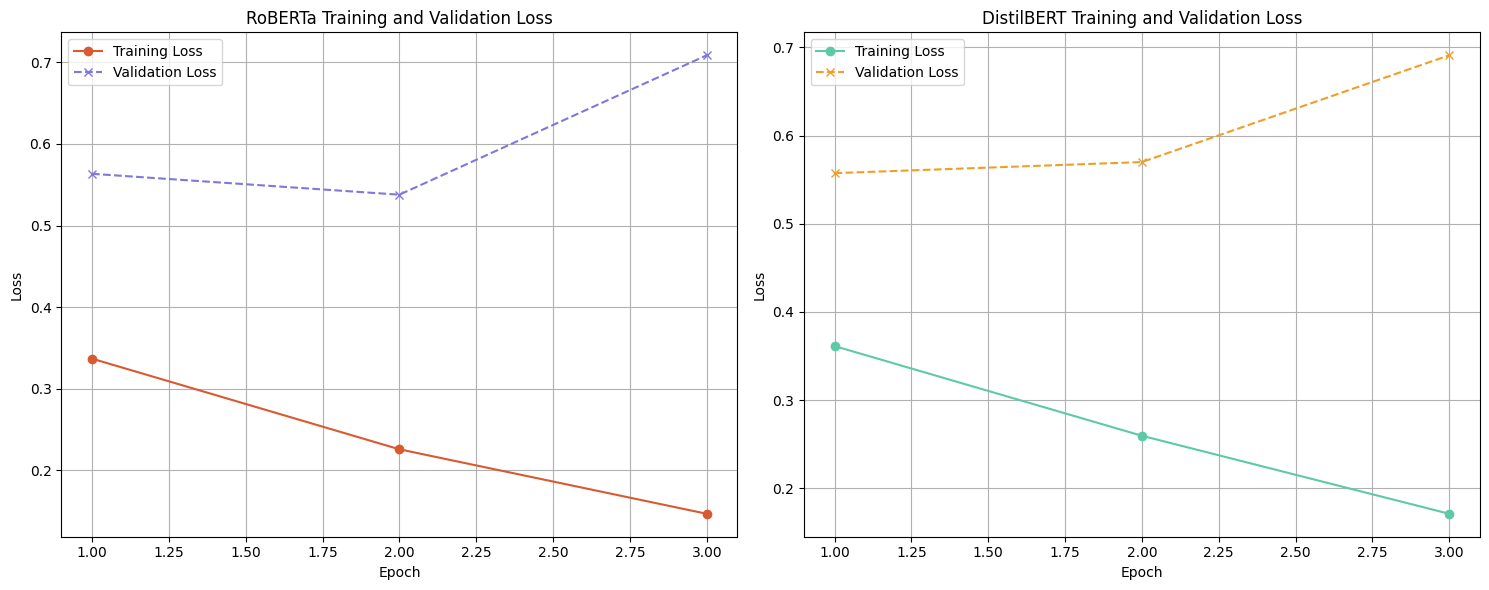

In [ ]:
if USE_ROBERTA:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # RoBERTa Loss Plot
    # Align epochs for plotting: use the length of the evaluation losses as the common dimension
    num_eval_epochs_roberta = len(roberta_eval_losses)
    epochs_roberta = range(1, num_eval_epochs_roberta + 1)
    # Slice training losses to match the number of evaluation epochs (assuming eval starts after first training epoch)
    aligned_roberta_training_losses = roberta_training_losses[1:num_eval_epochs_roberta+1]

    axes[0].plot(epochs_roberta, aligned_roberta_training_losses, label='Training Loss', marker='o', linestyle='-', color='#D85A30')
    axes[0].plot(epochs_roberta, roberta_eval_losses, label='Validation Loss', marker='x', linestyle='--', color='#7F77DD')
    axes[0].set_title('RoBERTa Training and Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # DistilBERT Loss Plot
    # Align epochs for plotting: use the length of the evaluation losses as the common dimension
    num_eval_epochs_distilbert = len(distilbert_eval_losses)
    epochs_distilbert = range(1, num_eval_epochs_distilbert + 1)
    # Slice training losses to match the number of evaluation epochs
    aligned_distilbert_training_losses = distilbert_training_losses[1:num_eval_epochs_distilbert+1]

    axes[1].plot(epochs_distilbert, aligned_distilbert_training_losses, label='Training Loss', marker='o', linestyle='-', color='#5DCAA5')
    axes[1].plot(epochs_distilbert, distilbert_eval_losses, label='Validation Loss', marker='x', linestyle='--', color='#EF9F27')
    axes[1].set_title('DistilBERT Training and Validation Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()
else:
    print('Training loss curves skipped — no GPU was used for training.')


=== Model Comparison ===


,Model,Accuracy,F1,Precision,Recall
0,Logistic Regression,68.78,70.76,66.54,75.56
1,XGBoost (System A),69.00,70.79,66.93,75.11
2,RoBERTa + context (System B),75.83,77.79,71.95,84.67
3,DistilBERT + context (System C),72.78,75.81,68.21,85.33


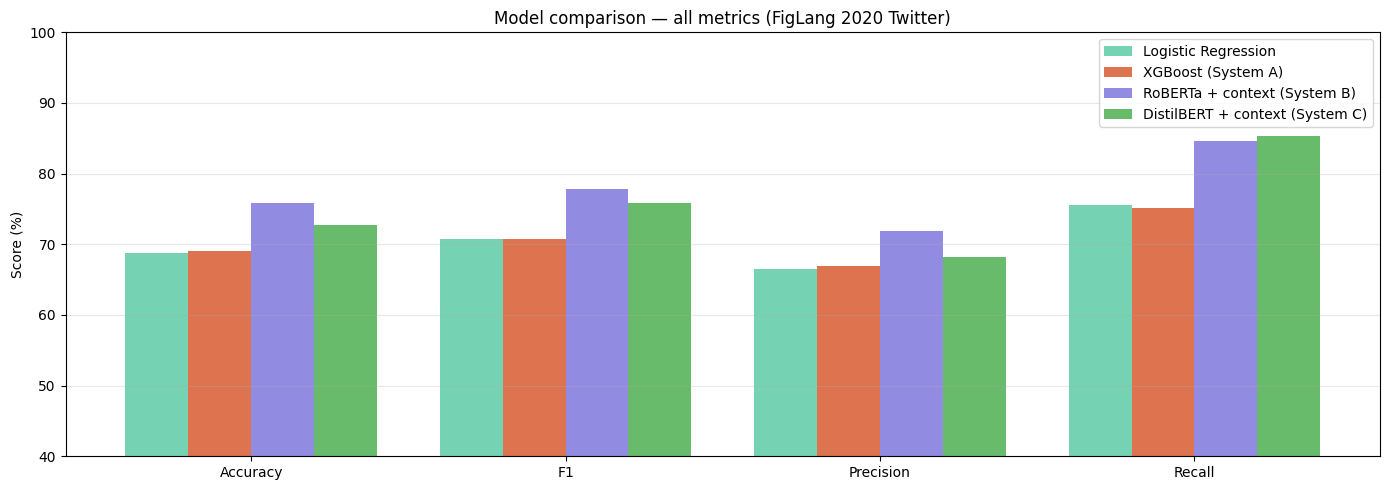

In [ ]:
def get_metrics(y_true, y_pred, name):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score( y_true, y_pred) * 100, 2),
        'F1'       : round(f1_score(        y_true, y_pred) * 100, 2),
        'Precision': round(precision_score( y_true, y_pred) * 100, 2),
        'Recall'   : round(recall_score(    y_true, y_pred) * 100, 2),
    }

results = [
    get_metrics(y_test, y_pred_lr,  'Logistic Regression'),
    get_metrics(y_test, y_pred_xgb, 'XGBoost (System A)'),
]
if roberta_results:
    results.append({
        'Model'    : 'RoBERTa + context (System B)',
        'Accuracy' : round(roberta_results['accuracy']  * 100, 2),
        'F1'       : round(roberta_results['f1']        * 100, 2),
        'Precision': round(roberta_results['precision'] * 100, 2),
        'Recall'   : round(roberta_results['recall']    * 100, 2),
    })
if distilbert_results: # Add DistilBERT results
    results.append({
        'Model'    : 'DistilBERT + context (System C)',
        'Accuracy' : round(distilbert_results['accuracy']  * 100, 2),
        'F1'       : round(distilbert_results['f1']        * 100, 2),
        'Precision': round(distilbert_results['precision'] * 100, 2),
        'Recall'   : round(distilbert_results['recall']    * 100, 2),
    })

results_df = pd.DataFrame(results)
print('\n=== Model Comparison ===')
display(results_df)

metrics = ['Accuracy', 'F1', 'Precision', 'Recall']
x       = np.arange(len(metrics))
width   = 0.20 # Adjusted width for more bars
colors  = ['#5DCAA5', '#D85A30', '#7F77DD', '#4CAF50'] # Added a new color for DistilBERT

fig, ax = plt.subplots(figsize=(14, 5)) # Slightly wider figure
for i, row in results_df.iterrows():
    vals = [row[m] for m in metrics]
    ax.bar(x + i * width, vals, width, label=row['Model'],
           color=colors[i % len(colors)], alpha=0.85)

ax.set_xticks(x + width * (len(results_df) - 1) / 2)
ax.set_xticklabels(metrics)
ax.set_ylim(40, 100)
ax.set_ylabel('Score (%)')
ax.set_title('Model comparison — all metrics (FigLang 2020 Twitter)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### F1-Score Comparison Across Models

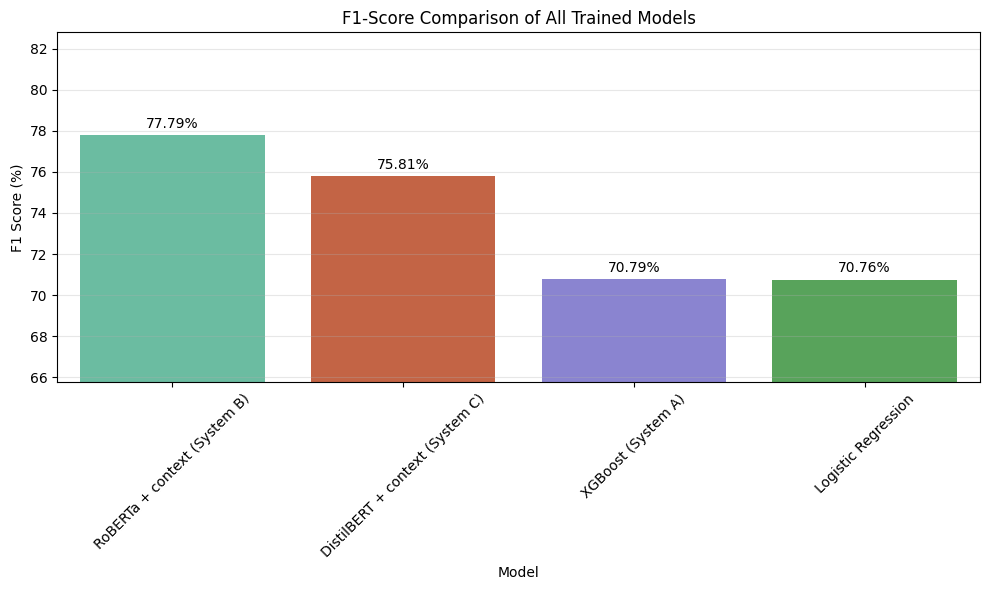

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(x='Model', y='F1', data=results_df.sort_values(by='F1', ascending=False),
            palette=colors, ax=ax)

# Add F1 score values on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', label_type='edge', padding=3)

ax.set_ylim(results_df['F1'].min() - 5, results_df['F1'].max() + 5) # Adjust y-axis limits
ax.set_title('F1-Score Comparison of All Trained Models')
ax.set_xlabel('Model')
ax.set_ylabel('F1 Score (%)')
ax.tick_params(axis='x', rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

##Ablation Study

In [ ]:
FEATURE_GROUPS = {
    'baseline'    : ['vader_compound','vader_pos','vader_neg','vader_neu',
                     'pos_adj_ratio','pos_adv_ratio','pos_verb_ratio',
                     'type_token_ratio','avg_word_length','word_count'],
    'rhetorical'  : ['polarity_gap_score','starts_fake_agree','has_rhetorical_q',
                     'neg_pos_score','neg_exclaim'],
    'casing'      : ['caps_ratio','caps_words_ratio','mixed_casing'],
    'punctuation' : ['exclaim_count','question_count','multi_exclaim',
                     'multi_question','interrobang','ellipsis'],
    'intensifiers': ['intensifier_count','intensifier_density','intensifier_combo_score'],
    'incongruity' : ['sent_vader_variance','sent_vader_range',
                     'incongruity_score','incongruity_sign_flip'],
    'context'     : ['parent_sentiment','response_sentiment','context_sentiment_gap',
                     'context_flip','context_pos_to_neg','context_topic_sim'],
    'emoji'       : ['emoji_count','emoji_sarcastic','emoji_positive',
                     'emoji_negative','emoji_sentiment_mismatch','emoji_density'],
    'twitter'     : ['hashtag_count','mention_count','has_url',
                     'is_retweet','char_count','has_sarcasm_hashtag'],
    'hyperbole'   : ['superlative_count','exaggeration_count','irony_opener',
                     'obviousness_count','positive_then_negative','contrast_conjunctions'],
}

ABLATION_VARIANTS = [
    ('Baseline',          ['baseline']),
    ('+ Rhetorical',      ['baseline','rhetorical']),
    ('+ Casing',          ['baseline','casing']),
    ('+ Punctuation',     ['baseline','punctuation']),
    ('+ Intensifiers',    ['baseline','intensifiers']),
    ('+ Incongruity',     ['baseline','incongruity']),
    ('+ Context',         ['baseline','context']),
    ('+ Emoji',           ['baseline','emoji']),
    ('+ Twitter',         ['baseline','twitter']),
    ('+ Hyperbole/Irony', ['baseline','hyperbole']),
    ('All features',      list(FEATURE_GROUPS.keys())),
]


def run_ablation(train_feats, test_feats, y_train, y_test):
    results = []
    for name, groups in tqdm(ABLATION_VARIANTS, desc='Ablation'):
        cols = [c for g in groups for c in FEATURE_GROUPS[g]]
        Xtr  = train_feats[cols].values
        Xte  = test_feats[cols].values
        m = XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            use_label_encoder=False, eval_metric='logloss',
            random_state=SEED, n_jobs=-1, verbosity=0)
        m.fit(Xtr, y_train)
        y_pred = m.predict(Xte)
        results.append({
            'Variant'  : name,
            'Accuracy' : round(accuracy_score( y_test, y_pred) * 100, 2),
            'F1'       : round(f1_score(        y_test, y_pred) * 100, 2),
            'Precision': round(precision_score( y_test, y_pred) * 100, 2),
            'Recall'   : round(recall_score(    y_test, y_pred) * 100, 2),
        })
    return pd.DataFrame(results)


ablation_df = run_ablation(train_feats, test_feats, y_train, y_test)
print('\n=== Ablation Study Results ===')
display(ablation_df)

Ablation:   0%|          | 0/11 [00:00<?, ?it/s]


=== Ablation Study Results ===


,Variant,Accuracy,F1,Precision,Recall
0,Baseline,58.61,58.22,58.78,57.67
1,+ Rhetorical,58.44,58.12,58.58,57.67
2,+ Casing,60.50,61.34,60.06,62.67
3,+ Punctuation,59.78,59.00,60.16,57.89
4,+ Intensifiers,59.06,59.03,59.07,59.00
5,+ Incongruity,59.00,59.05,58.98,59.11
6,+ Context,61.22,61.77,60.91,62.67
7,+ Emoji,59.00,58.31,59.31,57.33
8,+ Twitter,63.56,65.40,62.25,68.89
9,+ Hyperbole/Irony,59.94,59.61,60.11,59.11


In [ ]:
# Train final model using ALL handcrafted features (for SHAP + demo)
print('Training final XGBoost on ALL handcrafted features...')
xgb_final = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.08,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='logloss',
    random_state=SEED, n_jobs=-1, verbosity=0)
xgb_final.fit(X_train_hc, y_train)
y_pred_final = xgb_final.predict(X_test_hc)
print('\n=== Final Model (All Handcrafted Features) ===')
print(classification_report(y_test, y_pred_final,
                             target_names=['Non-sarcastic', 'Sarcastic']))

Training final XGBoost on ALL handcrafted features...

=== Final Model (All Handcrafted Features) ===
               precision    recall  f1-score   support

Non-sarcastic       0.67      0.62      0.64       900
    Sarcastic       0.65      0.70      0.67       900

     accuracy                           0.66      1800
    macro avg       0.66      0.66      0.66      1800
 weighted avg       0.66      0.66      0.66      1800



In [ ]:
import joblib
joblib.dump(xgb_final, "xgb_sarcasm_model.joblib")

['xgb_sarcasm_model.joblib']

##Visualizations

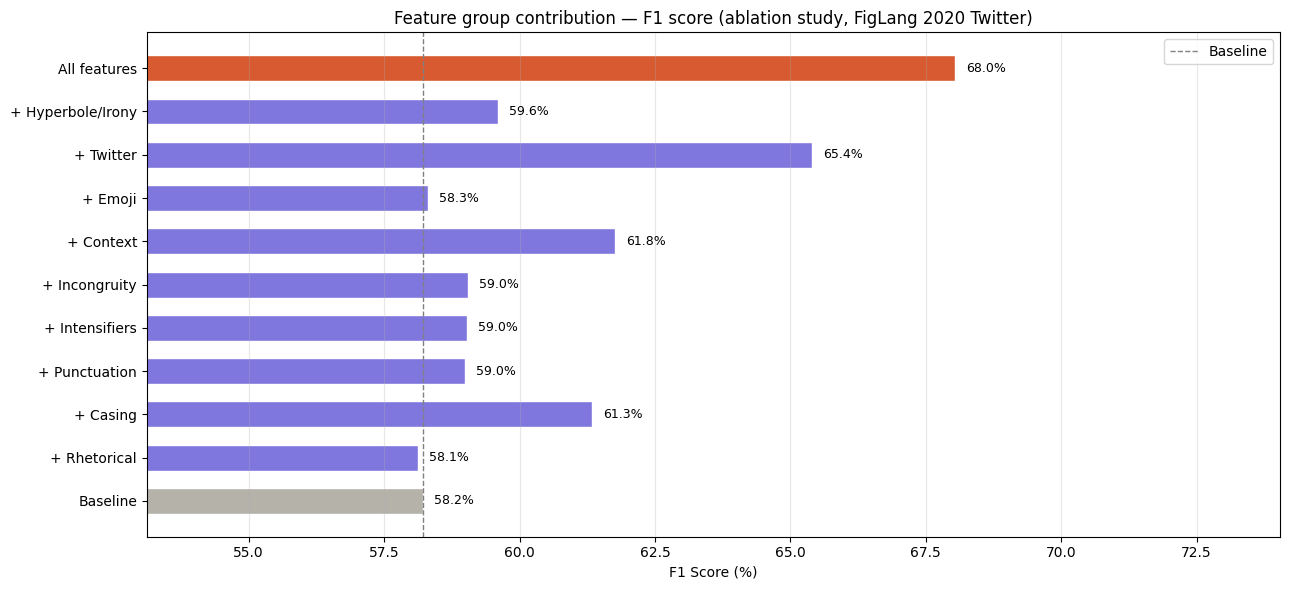

In [ ]:
# 1. F1 bar chart — ablation study
palette = ['#B4B2A9'] + ['#7F77DD'] * (len(ablation_df) - 2) + ['#D85A30']

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(ablation_df['Variant'], ablation_df['F1'],
               color=palette, edgecolor='white', height=0.6)

for bar, val in zip(bars, ablation_df['F1']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

baseline_f1 = ablation_df.loc[ablation_df['Variant'] == 'Baseline', 'F1'].values[0]
ax.axvline(baseline_f1, color='gray', linestyle='--', linewidth=1, label='Baseline')
ax.set_xlabel('F1 Score (%)')
ax.set_title('Feature group contribution — F1 score (ablation study, FigLang 2020 Twitter)')
ax.set_xlim(ablation_df['F1'].min() - 5, ablation_df['F1'].max() + 6)
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

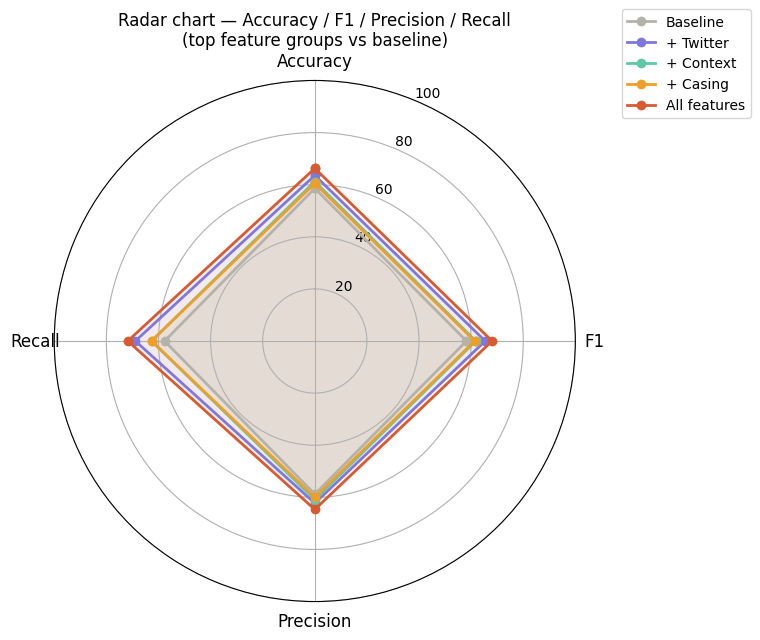

In [ ]:
# 2. Radar chart
categories = ['Accuracy', 'F1', 'Precision', 'Recall']
N      = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

individual = ablation_df[~ablation_df['Variant'].isin(['Baseline','All features'])]
top3       = individual.nlargest(3, 'F1')['Variant'].tolist()
highlight  = ['Baseline'] + top3 + ['All features']
colors_r   = ['#B4B2A9', '#7F77DD', '#5DCAA5', '#EF9F27', '#D85A30']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_ylim(0, 100)

for label, color in zip(highlight, colors_r):
    row_data = ablation_df[ablation_df['Variant'] == label]
    if row_data.empty: continue
    row  = row_data.iloc[0]
    vals = [row[c] for c in categories] + [row[categories[0]]]
    ax.plot(angles, vals, 'o-', linewidth=2, label=label, color=color)
    ax.fill(angles, vals, alpha=0.07, color=color)

ax.set_title('Radar chart — Accuracy / F1 / Precision / Recall\n(top feature groups vs baseline)',
             size=12, pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.show()

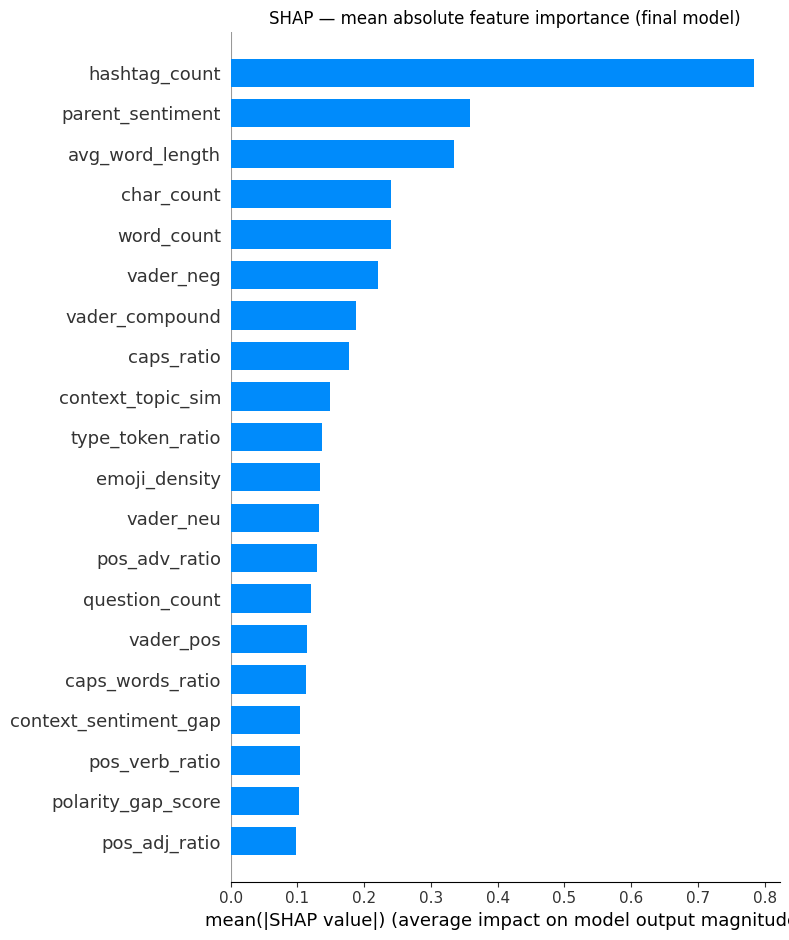

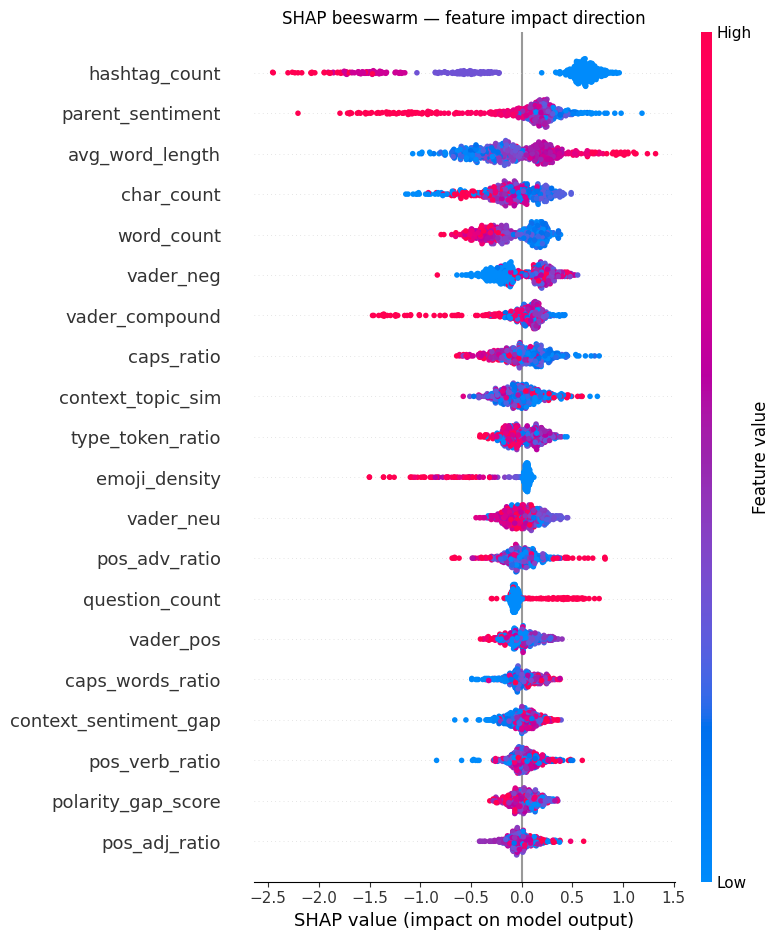

In [ ]:
# 3. SHAP feature importance
explainer   = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test_hc[:500])

plt.figure(figsize=(11, 9))
shap.summary_plot(shap_values, X_test_hc[:500],
                  feature_names=train_feats.columns.tolist(),
                  show=False, plot_type='bar')
plt.title('SHAP — mean absolute feature importance (final model)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 9))
shap.summary_plot(shap_values, X_test_hc[:500],
                  feature_names=train_feats.columns.tolist(),
                  show=False)
plt.title('SHAP beeswarm — feature impact direction')
plt.tight_layout()
plt.show()

### Local SHAP Explanation (Per Prediction)

This section adds functionality to explain individual predictions using SHAP, showing the top contributing features for a given input (context + reply).

Original Response: @USER @USER Define this way : 1 . Desiring the good of the other ; wanting them to thrive / flourish , which means they'd get free from the attitudes you mention ; 2 . Doing whatever's in your control / power to advance their good ; at least * not * wishing them ill , * not * hating them . @USER
Original Parent: @USER Ok , you ’ re right , but how do you love someone who hates you , and wants you to not exist ? How do you love someone doesn ’ t share basic morals ?
Actual Label: Non-sarcastic


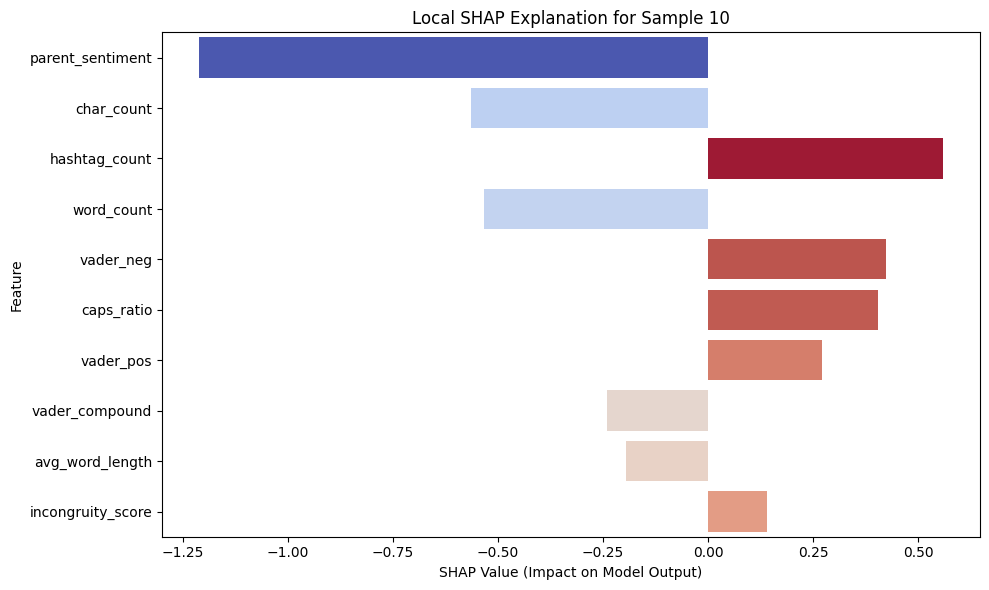

In [ ]:
def plot_local_shap(model, X_data, feature_names, sample_idx):
    explainer = shap.TreeExplainer(model)
    # Reshape X_data[sample_idx] to be a 2D array (1 sample, n features)
    input_for_shap = X_data[sample_idx].reshape(1, -1)
    shap_values_raw = explainer.shap_values(input_for_shap)

    # Determine the SHAP values for the class of interest (e.g., sarcastic = 1)
    # For binary classification, shap_values_raw is typically [shap_for_class_0, shap_for_class_1]
    if isinstance(shap_values_raw, list):
        # We want to explain the positive class (sarcastic, which is 1) given the context of sarcasm detection.
        # This assumes the second element (index 1) corresponds to the positive class.
        shap_values = shap_values_raw[1]
    else:
        # If not a list, it's a single array (e.g., for single output model or if shap_values for one class is returned)
        shap_values = shap_values_raw

    # Ensure shap_values is a 1D array before passing to DataFrame constructor
    # It might still be a 2D array like [[v1, v2, ...]] at this point, so flatten it.
    if shap_values.ndim > 1:
        shap_values = shap_values.flatten()

    # Create a DataFrame for better handling and sorting
    local_shap_df = pd.DataFrame({
        'feature': feature_names,
        'shap_value': shap_values,
        'feature_value': X_data[sample_idx]
    })

    # Sort by absolute SHAP value to get most impactful features
    local_shap_df['abs_shap_value'] = local_shap_df['shap_value'].abs()
    local_shap_df = local_shap_df.sort_values(by='abs_shap_value', ascending=False).head(10)

    # Plotting
    fig = plt.figure(figsize=(10, 6))
    sns.barplot(x='shap_value', y='feature', data=local_shap_df, palette='coolwarm', hue='shap_value', dodge=False, legend=False)
    plt.title(f'Local SHAP Explanation for Sample {sample_idx}')
    plt.xlabel('SHAP Value (Impact on Model Output)')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

# Example: Choose a sample from the test set to explain
example_index = 10 # You can change this to any index in the test set

print(f"Original Response: {test_df.iloc[example_index]['response']}")
print(f"Original Parent: {test_df.iloc[example_index]['parent']}")
print(f"Actual Label: {'Sarcastic' if y_test[example_index] == 1 else 'Non-sarcastic'}")

# Plot local SHAP values for an example
plot_local_shap(xgb_final, X_test_hc, train_feats.columns.tolist(), example_index)


### Human-Readable Explanation Layer (Rule-Based)

This function translates the engineered features into plain language explanations, based on simple threshold-based rules. It aims to provide intuitive reasons behind the sarcasm prediction.

In [ ]:
def generate_human_explanation(features_series, predicted_label):
    explanation = []

    # Convert feature series to a dictionary for easier access
    feats = features_series.to_dict()

    # Predicted label for display
    prediction_text = 'Sarcastic' if predicted_label == 1 else 'Non-sarcastic'

    # Rule 1: Sentiment Incongruity
    if feats['incongruity_sign_flip'] == 1 or feats['sent_vader_range'] > 0.6:
        explanation.append("Sentiment incongruity (e.g., positive start, negative end, or high sentiment range).")

    # Rule 2: High Polarity Gap (Rhetorical)
    if feats['polarity_gap_score'] > 0.4 and predicted_label == 1:
        explanation.append("Significant sentiment polarity gap within the text, typical in sarcasm.")

    # Rule 3: Punctuation Intensity
    if feats['multi_exclaim'] == 1 or feats['multi_question'] == 1 or feats['interrobang'] == 1 or feats['ellipsis'] == 1:
        explanation.append("Intense punctuation usage (e.g., '!!', '??', '?!', '...').")

    # Rule 4: Casing (ALL-CAPS words)
    if feats['caps_words_ratio'] > 0.1 or feats['mixed_casing'] == 1:
        explanation.append("Use of capitalized words or mixed casing.")

    # Rule 5: Intensifiers
    if feats['intensifier_density'] > 0.05:
        explanation.append("High density of intensifier words (e.g., 'very', 'really').")

    # Rule 6: Context Mismatch
    if feats['context_flip'] == 1 or feats['context_sentiment_gap'] > 0.5:
        explanation.append("Sentiment contradiction between context and reply.")
    if feats['context_topic_sim'] < 0.2 and predicted_label == 1: # Low similarity can imply sarcastic divergence
        explanation.append("Low topic similarity with the parent context.")

    # Rule 7: Sarcastic Emojis
    if feats['emoji_sarcastic'] == 1:
        explanation.append("Presence of emojis often associated with sarcasm (e.g., 🙄, 😒).")

    # Rule 8: Hyperbole/Irony markers
    if feats['exaggeration_count'] > 0 or feats['superlative_count'] > 0 or feats['irony_opener'] == 1:
        explanation.append("Indicators of hyperbole or irony (e.g., superlatives, irony openers).")

    # Rule 9: Negative Exclamations
    if feats['neg_exclaim'] == 1:
        explanation.append("Negative sentiment combined with exclamations.")

    # Default explanation if no specific rules are triggered for sarcasm
    if not explanation and predicted_label == 1:
        explanation.append("General sarcastic indicators not captured by specific rules.")
    elif not explanation and predicted_label == 0:
        explanation.append("No strong indicators of sarcasm found.")

    return f"Prediction: {prediction_text}\nReason:\n" + "\n".join([f"- {reason}" for reason in explanation])

print('Human-readable explanation function defined.')


Human-readable explanation function defined.


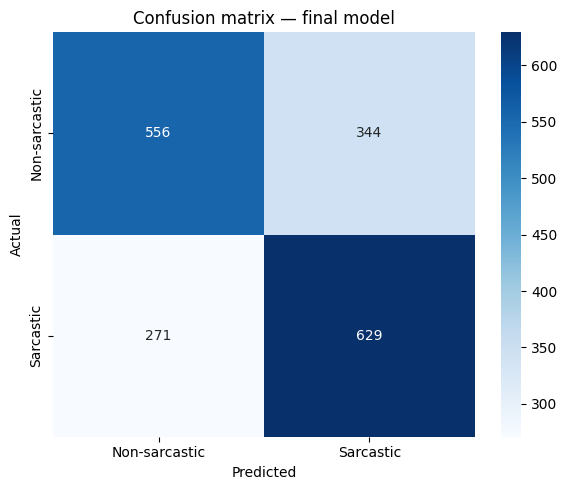

In [ ]:
# 4. Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-sarcastic','Sarcastic'],
            yticklabels=['Non-sarcastic','Sarcastic'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion matrix — final model')
plt.tight_layout()
plt.show()

### Confusion Matrices: RoBERTa vs. DistilBERT

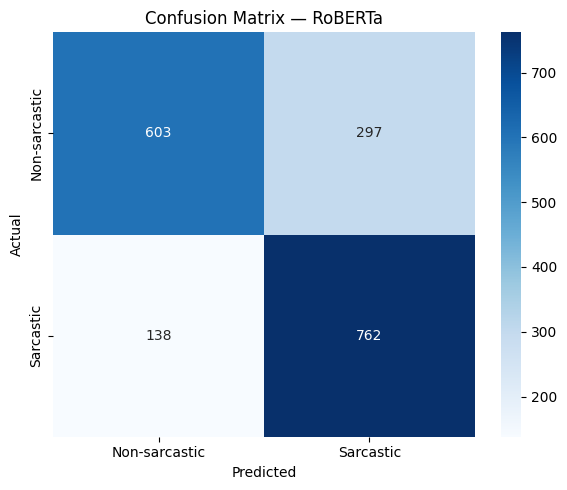

In [ ]:
if USE_ROBERTA:
    # RoBERTa Confusion Matrix
    cm_roberta = confusion_matrix(y_test, y_pred_roberta)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_roberta, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-sarcastic','Sarcastic'],
                yticklabels=['Non-sarcastic','Sarcastic'], ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title('Confusion Matrix — RoBERTa')
    plt.tight_layout()
    plt.show()
else:
    print('RoBERTa confusion matrix skipped — no GPU was used for training.')

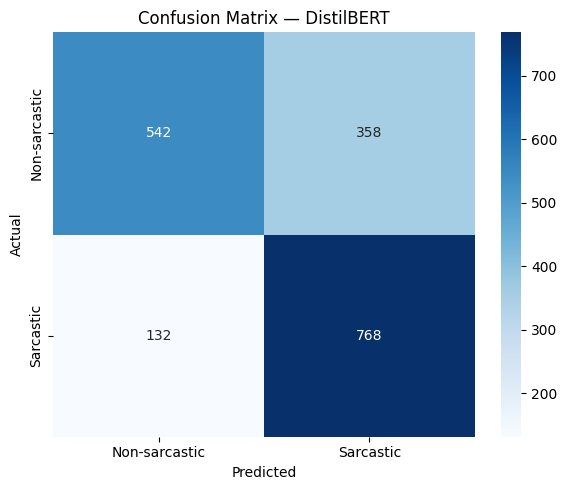

In [ ]:
if USE_ROBERTA:
    # DistilBERT Confusion Matrix
    cm_distilbert = confusion_matrix(y_test, y_pred_distilbert)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_distilbert, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-sarcastic','Sarcastic'],
                yticklabels=['Non-sarcastic','Sarcastic'], ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title('Confusion Matrix — DistilBERT')
    plt.tight_layout()
    plt.show()
else:
    print('DistilBERT confusion matrix skipped — no GPU was used for training.')

### Integration into Prediction Pipeline (Transformer Models)

This section demonstrates how to integrate the explanation generation after the prediction step for Transformer models (RoBERTa and DistilBERT). This requires re-extracting handcrafted features for the specific sample.

In [ ]:
def predict_and_explain_transformer(model_trainer, tokenizer, original_response, original_parent, actual_label, tfidf_ctx_vec, feature_names):
    # Prepare data for transformer prediction
    single_response = original_response
    single_parent   = original_parent
    single_label    = actual_label

    # Create a dummy dataset for a single prediction
    single_dataset = SarcasmDatasetContext([single_response], [single_parent], [single_label], tokenizer)

    # Make prediction with the transformer model
    preds = model_trainer.predict(single_dataset)
    prediction = np.argmax(preds.predictions, axis=1)[0]

    # Extract handcrafted features for the single sample to feed into human-readable explanation
    temp_df = pd.DataFrame([{'response': single_response, 'parent': single_parent, 'label': single_label}])
    single_sample_feats_df = extract_all_features(temp_df, tfidf_ctx_vec)
    single_sample_features = single_sample_feats_df.iloc[0]

    # Generate human-readable explanation
    human_explanation = generate_human_explanation(single_sample_features, prediction)

    print(f"\n--- Prediction and Explanation (Transformer Model) ---")
    print(f"Response: {single_response}")
    print(f"Parent: {single_parent}")
    print(f"Actual Label: {'Sarcastic' if actual_label == 1 else 'Non-sarcastic'}")
    print(f"Predicted Label: {'Sarcastic' if prediction == 1 else 'Non-sarcastic'}")
    print(human_explanation)

    # Note: SHAP for transformer models is more complex and typically requires specialized libraries like `shap.DeepExplainer`
    # or `shap.PartitionExplainer` which are computationally intensive and beyond the scope of a simple local explanation here.
    # The human-readable explanation still provides valuable insights based on engineered features.

# Example usage for RoBERTa (System B)
if USE_ROBERTA and roberta_trainer:
    example_index_roberta = 30 # Choose an example index
    print(f"\n--- RoBERTa Explanation for Sample {example_index_roberta} ---")
    predict_and_explain_transformer(
        roberta_trainer,
        roberta_tokenizer,
        test_df.iloc[example_index_roberta]['response'],
        test_df.iloc[example_index_roberta]['parent'],
        y_test[example_index_roberta],
        tfidf_ctx,
        train_feats.columns.tolist()
    )

# Example usage for DistilBERT (System C)
if USE_ROBERTA and distilbert_trainer: # USE_ROBERTA is reused for general GPU availability
    example_index_distilbert = 30 # Choose a different example index
    print(f"\n--- DistilBERT Explanation for Sample {example_index_distilbert} ---")
    predict_and_explain_transformer(
        distilbert_trainer,
        distilbert_tokenizer,
        test_df.iloc[example_index_distilbert]['response'],
        test_df.iloc[example_index_distilbert]['parent'],
        y_test[example_index_distilbert],
        tfidf_ctx,
        train_feats.columns.tolist()
    )



--- RoBERTa Explanation for Sample 30 ---


Extracting features:   0%|          | 0/1 [00:00<?, ?it/s]


--- Prediction and Explanation (Transformer Model) ---
Response: @USER @USER @USER I could handle Gabbard / Sanders . Bernie makes good insurance and if Tulsi could get out from under the party parrot barf she'd likely set the world on fire . Too bad they're trying to undermine her for old white men . Oh wait ...
Parent: @USER @USER @USER Only if Tulsi is the Prez ... Next to Tulsi , it has to be Bernie .. no one else comes even close as the nominee choice for me
Actual Label: Sarcastic
Predicted Label: Sarcastic
Prediction: Sarcastic
Reason:
- Sentiment incongruity (e.g., positive start, negative end, or high sentiment range).
- Significant sentiment polarity gap within the text, typical in sarcasm.
- Intense punctuation usage (e.g., '!!', '??', '?!', '...').

--- DistilBERT Explanation for Sample 30 ---


Extracting features:   0%|          | 0/1 [00:00<?, ?it/s]


--- Prediction and Explanation (Transformer Model) ---
Response: @USER @USER @USER I could handle Gabbard / Sanders . Bernie makes good insurance and if Tulsi could get out from under the party parrot barf she'd likely set the world on fire . Too bad they're trying to undermine her for old white men . Oh wait ...
Parent: @USER @USER @USER Only if Tulsi is the Prez ... Next to Tulsi , it has to be Bernie .. no one else comes even close as the nominee choice for me
Actual Label: Sarcastic
Predicted Label: Sarcastic
Prediction: Sarcastic
Reason:
- Sentiment incongruity (e.g., positive start, negative end, or high sentiment range).
- Significant sentiment polarity gap within the text, typical in sarcasm.
- Intense punctuation usage (e.g., '!!', '??', '?!', '...').


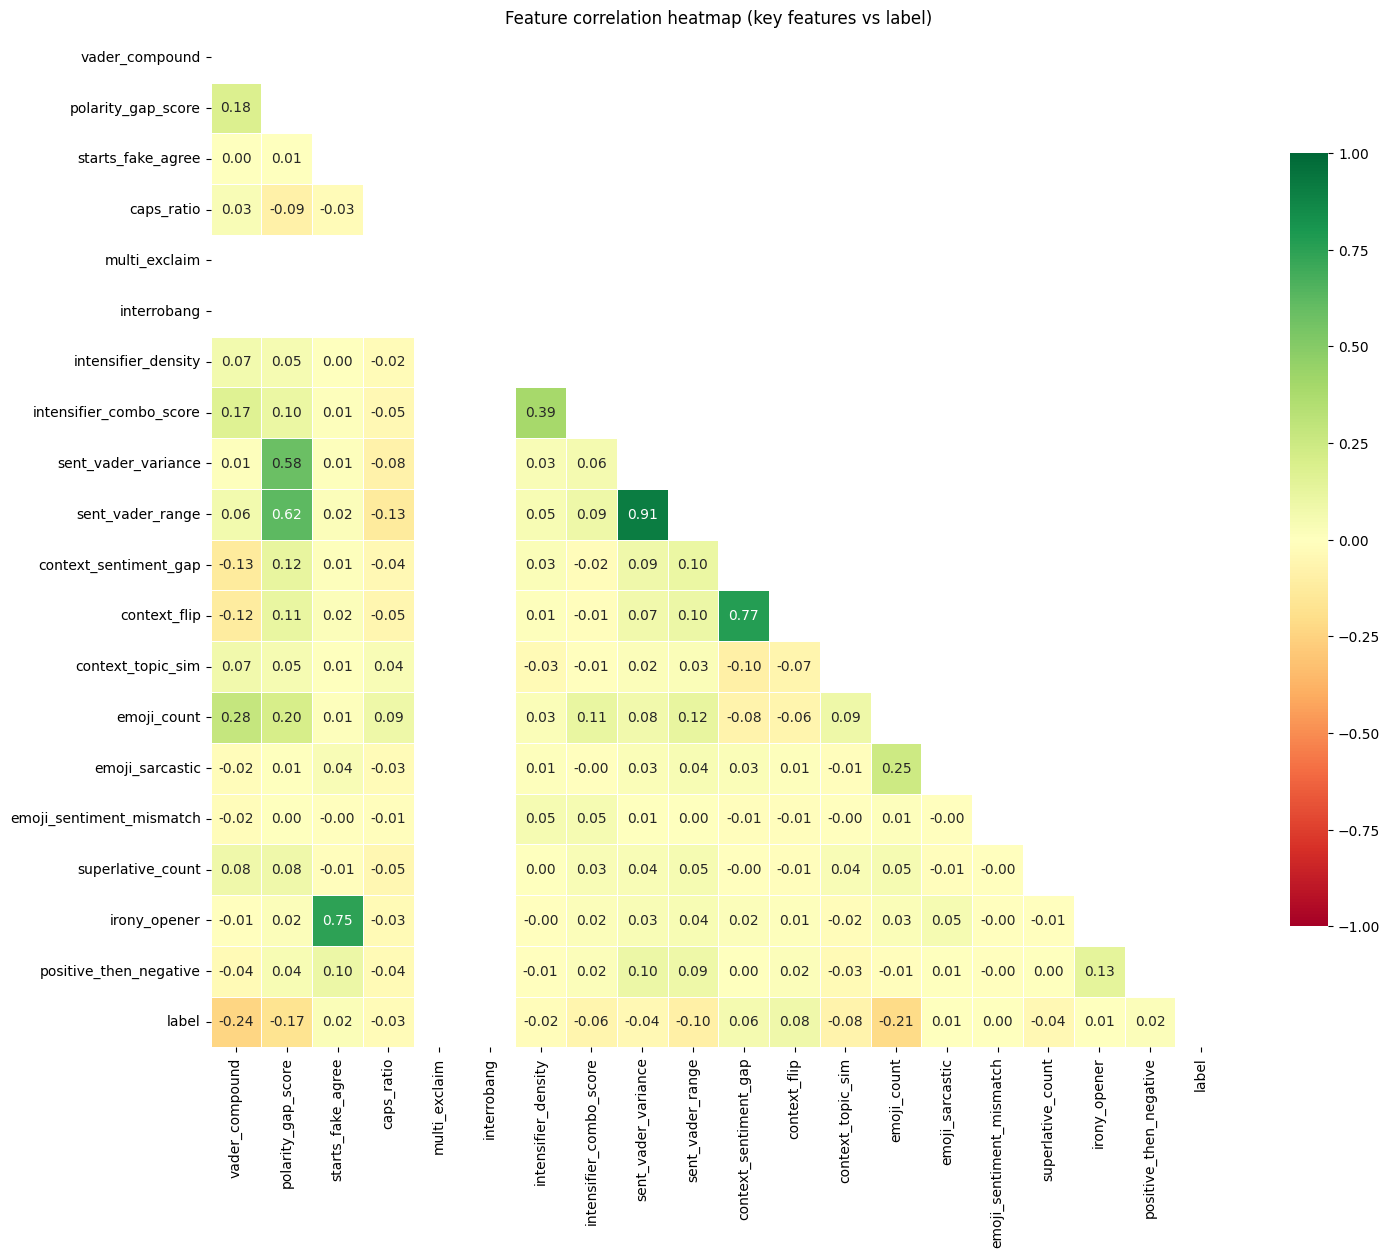

In [ ]:
# 5. Feature correlation heatmap (updated with new feature names)
key_features = [
    'vader_compound','polarity_gap_score','starts_fake_agree',
    'caps_ratio','multi_exclaim','interrobang',
    'intensifier_density','intensifier_combo_score',
    'sent_vader_variance','sent_vader_range',
    'context_sentiment_gap','context_flip','context_topic_sim',
    'emoji_count','emoji_sarcastic','emoji_sentiment_mismatch',
    'superlative_count','irony_opener','positive_then_negative'
]

corr_df = pd.concat([
    train_feats[key_features],
    pd.Series(y_train, name='label')
], axis=1).corr()

fig, ax = plt.subplots(figsize=(15, 13))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, cmap='RdYlGn', vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.4, ax=ax,
            square=True, cbar_kws={'shrink': 0.7})
ax.set_title('Feature correlation heatmap (key features vs label)')
plt.tight_layout()
plt.show()

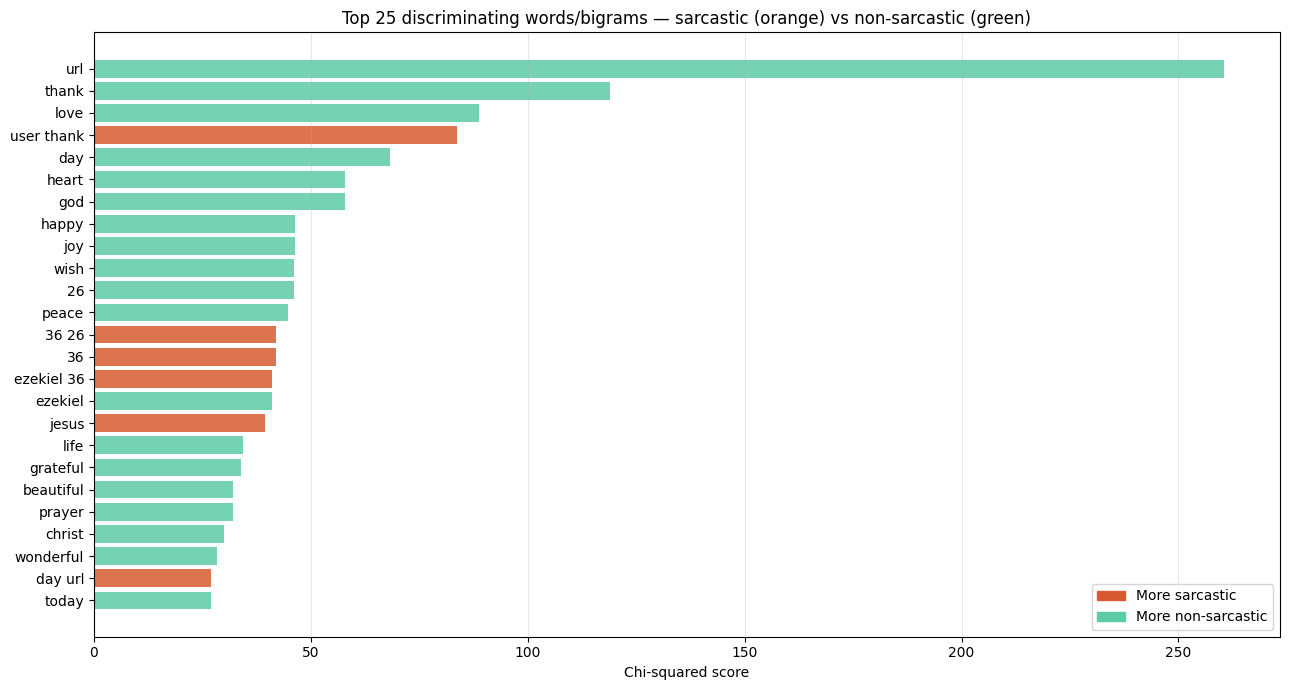

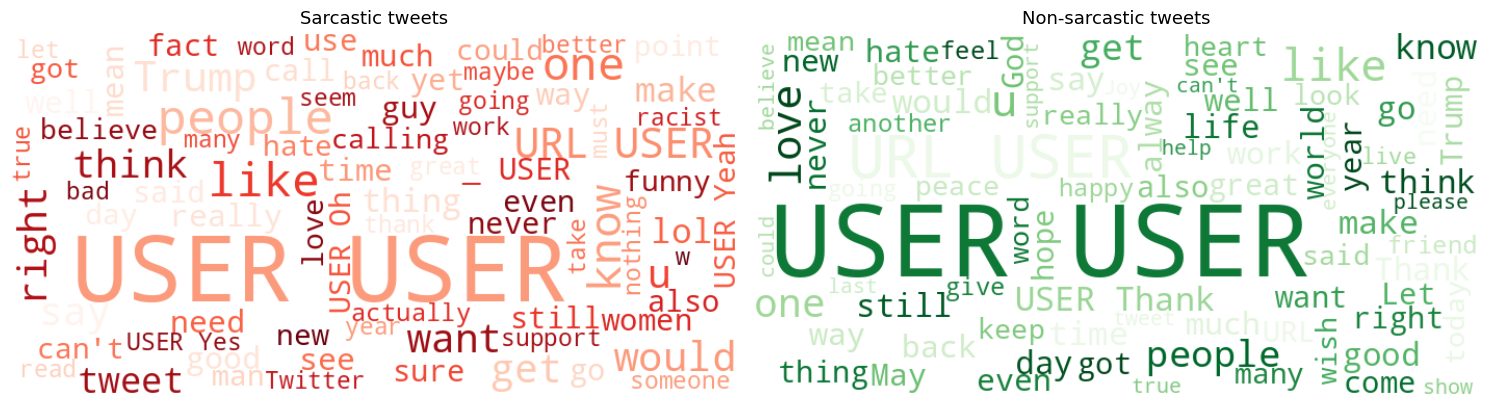

In [ ]:
# 6. Top discriminating words (chi-squared + word clouds)
cvec       = CountVectorizer(max_features=5000, ngram_range=(1,2),
                             stop_words='english', min_df=5)
X_cv       = cvec.fit_transform(train_df['response'])
chi2_scores, _ = chi2(X_cv, y_train)
vocab      = np.array(cvec.get_feature_names_out())
top_n      = 25
top_idx    = np.argsort(chi2_scores)[::-1][:top_n]
top_words  = vocab[top_idx]
top_scores = chi2_scores[top_idx]

sarc_texts  = ' '.join(train_df[y_train == 1]['response'])
nonsa_texts = ' '.join(train_df[y_train == 0]['response'])
sarc_freq   = {w: sarc_texts.lower().split().count(w)  for w in top_words}
nonsa_freq  = {w: nonsa_texts.lower().split().count(w) for w in top_words}
word_colors = ['#D85A30' if sarc_freq[w] >= nonsa_freq[w] else '#5DCAA5'
               for w in top_words]

fig, ax = plt.subplots(figsize=(13, 7))
ax.barh(top_words[::-1], top_scores[::-1],
        color=word_colors[::-1], alpha=0.85)
ax.set_xlabel('Chi-squared score')
ax.set_title('Top 25 discriminating words/bigrams — sarcastic (orange) vs non-sarcastic (green)')
patch_s  = mpatches.Patch(color='#D85A30', label='More sarcastic')
patch_ns = mpatches.Patch(color='#5DCAA5', label='More non-sarcastic')
ax.legend(handles=[patch_s, patch_ns])
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, text, title, cmap in zip(
        axes,
        [sarc_texts, nonsa_texts],
        ['Sarcastic tweets', 'Non-sarcastic tweets'],
        ['Reds', 'Greens']):
    wc = WordCloud(width=700, height=350, background_color='white',
                   colormap=cmap, max_words=80,
                   stopwords=STOPWORDS).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# 7. Interactive Plotly ablation chart
fig = go.Figure()
metric_colors = {
    'Accuracy' : '#7F77DD',
    'F1'       : '#D85A30',
    'Precision': '#5DCAA5',
    'Recall'   : '#EF9F27',
}
for metric, color in metric_colors.items():
    fig.add_trace(go.Bar(
        name=metric, x=ablation_df['Variant'], y=ablation_df[metric],
        marker_color=color, opacity=0.85))
fig.update_layout(
    barmode='group',
    title='Interactive ablation study — all metrics across feature groups (Twitter dataset)',
    xaxis_title='Feature variant',
    yaxis_title='Score (%)',
    yaxis=dict(range=[40, 100]),
    legend_title='Metric',
    height=520,
    template='plotly_white',
)
fig.show()